In [15]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
ROOT = Path.cwd().parent

# Allow imports from src/
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from data_loader import load_excel

print("Project root:", ROOT)
print("Python environment ready.")

Project root: c:\01-Sriram-MIT\VS\Hackathon\Powernext\cpri-powernext-ai
Python environment ready.


In [16]:
DATA_PATH = (
    ROOT
    / "data"
    / "raw"
    / "CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx"
)

train_df, test_df = load_excel(DATA_PATH)

print(f"Training shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Training shape: (1000, 11)
Test shape: (350, 9)


In [17]:
valid_df = train_df[
    train_df["Validity_Label"] == "Valid"
].copy()

invalid_df = train_df[
    train_df["Validity_Label"] == "Invalid"
].copy()

print("Training records :", len(train_df))
print("Valid records    :", len(valid_df))
print("Invalid records  :", len(invalid_df))
print("Test records     :", len(test_df))

Training records : 1000
Valid records    : 866
Invalid records  : 134
Test records     : 350


In [18]:
ID_COLUMN = "Test_ID"

OPERATING_COLUMNS = [
    "Applied_Voltage_kV",
    "Load_Current_A",
    "Ambient_Temperature_C",
    "Test_Duration_min",
]

SENSOR_COLUMNS = [
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
    "Sensor_S4",
]

PRIMARY_SENSOR_COLUMNS = [
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
]

TARGET_COLUMN = "Reference_Parameter"

LABEL_COLUMN = "Validity_Label"

NUMERIC_COLUMNS = (
    OPERATING_COLUMNS
    + SENSOR_COLUMNS
)

In [19]:
overview = pd.DataFrame(
    {
        "Dataset": [
            "Training",
            "Test",
        ],
        "Rows": [
            len(train_df),
            len(test_df),
        ],
        "Columns": [
            len(train_df.columns),
            len(test_df.columns),
        ],
    }
)

display(overview)

,Dataset,Rows,Columns
0,Training,1000,11
1,Test,350,9


In [20]:
quality = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_count": train_df.isna().sum(),
        "missing_pct": (
            train_df.isna().mean() * 100
        ).round(2),
        "unique_count": train_df.nunique(
            dropna=False
        ),
    }
)

display(quality)

,dtype,missing_count,missing_pct,unique_count
Test_ID,str,0,0.0,1000
Applied_Voltage_kV,float64,0,0.0,988
Load_Current_A,float64,0,0.0,988
Ambient_Temperature_C,float64,0,0.0,967
Test_Duration_min,float64,0,0.0,985
Sensor_S1,float64,6,0.6,976
Sensor_S2,float64,2,0.2,983
Sensor_S3,float64,7,0.7,975
Sensor_S4,float64,29,2.9,959
Reference_Parameter,float64,0,0.0,999


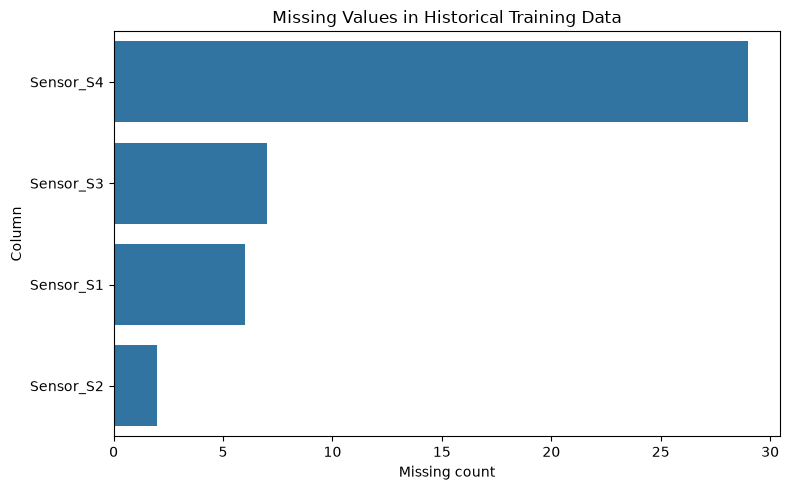

In [21]:
missing = (
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[
    missing > 0
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing.values,
    y=missing.index,
)

plt.title(
    "Missing Values in Historical Training Data"
)

plt.xlabel("Missing count")
plt.ylabel("Column")

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "01_training_missingness.png",
    dpi=200,
)

plt.show()

In [22]:
missing_by_validity = []

for label, group in train_df.groupby(
    LABEL_COLUMN
):

    for sensor in SENSOR_COLUMNS:

        missing_by_validity.append(
            {
                "Validity_Label": label,
                "Sensor": sensor,
                "Missing_Percentage": (
                    group[sensor]
                    .isna()
                    .mean()
                    * 100
                ),
            }
        )

missing_by_validity = pd.DataFrame(
    missing_by_validity
)

display(missing_by_validity)

,Validity_Label,Sensor,Missing_Percentage
0,Invalid,Sensor_S1,4.477612
1,Invalid,Sensor_S2,1.492537
2,Invalid,Sensor_S3,5.223881
3,Invalid,Sensor_S4,0.000000
4,Valid,Sensor_S1,0.000000
5,Valid,Sensor_S2,0.000000
6,Valid,Sensor_S3,0.000000
7,Valid,Sensor_S4,3.348730


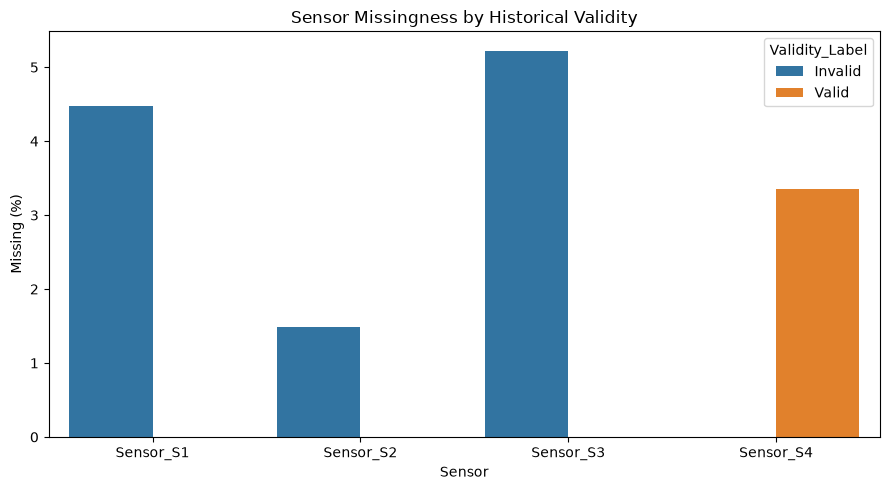

In [23]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=missing_by_validity,
    x="Sensor",
    y="Missing_Percentage",
    hue="Validity_Label",
)

plt.title(
    "Sensor Missingness by Historical Validity"
)

plt.ylabel("Missing (%)")

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "02_missingness_by_validity.png",
    dpi=200,
)

plt.show()

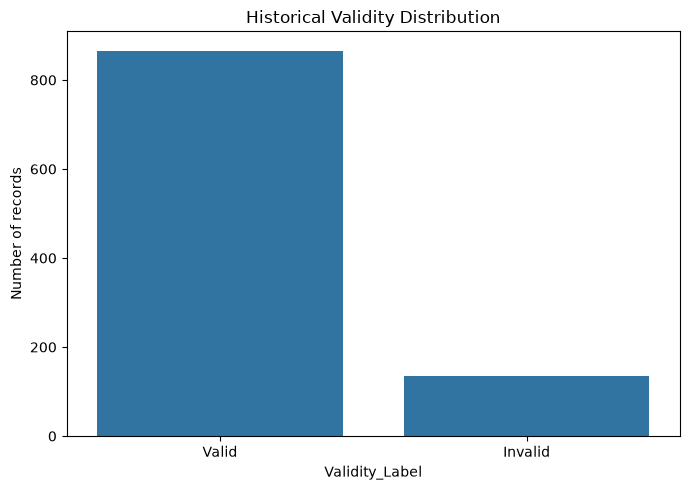

In [24]:
validity_counts = (
    train_df[LABEL_COLUMN]
    .value_counts()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=validity_counts.index,
    y=validity_counts.values,
)

plt.title(
    "Historical Validity Distribution"
)

plt.ylabel("Number of records")

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "03_validity_distribution.png",
    dpi=200,
)

plt.show()

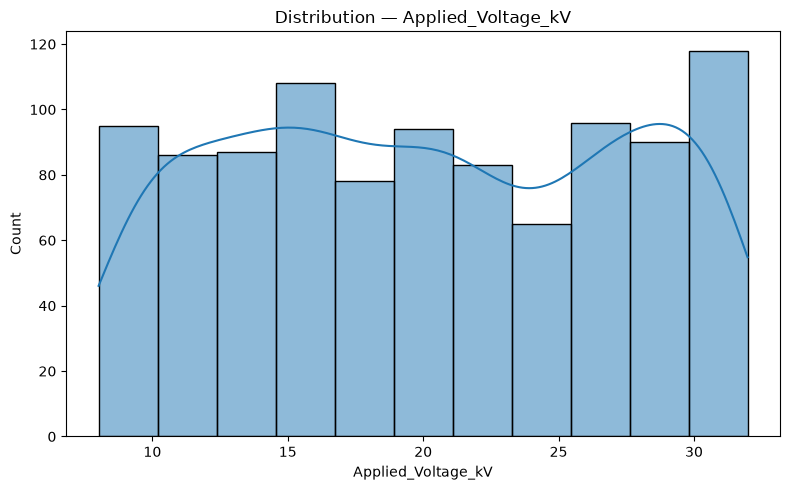

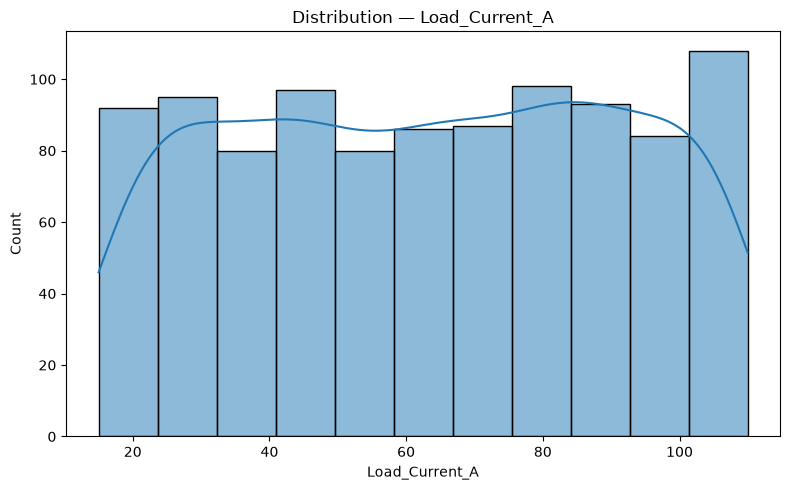

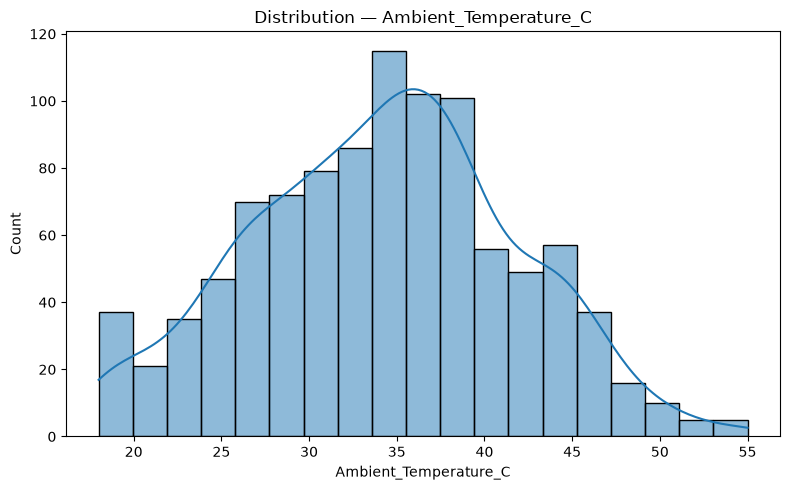

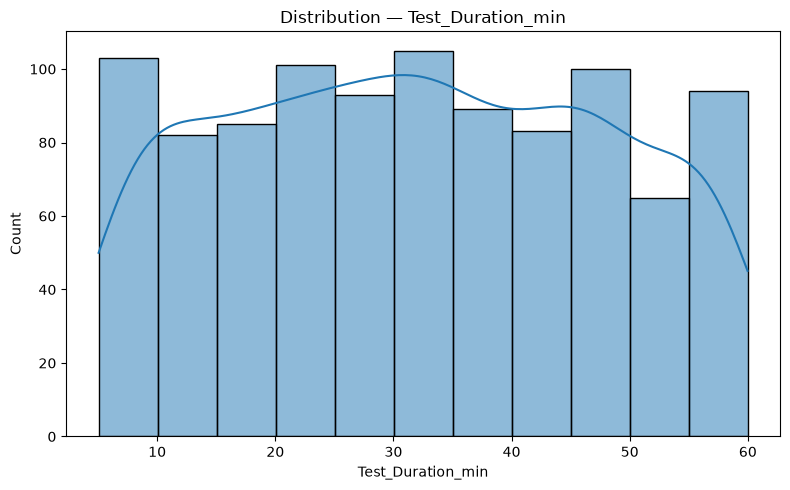

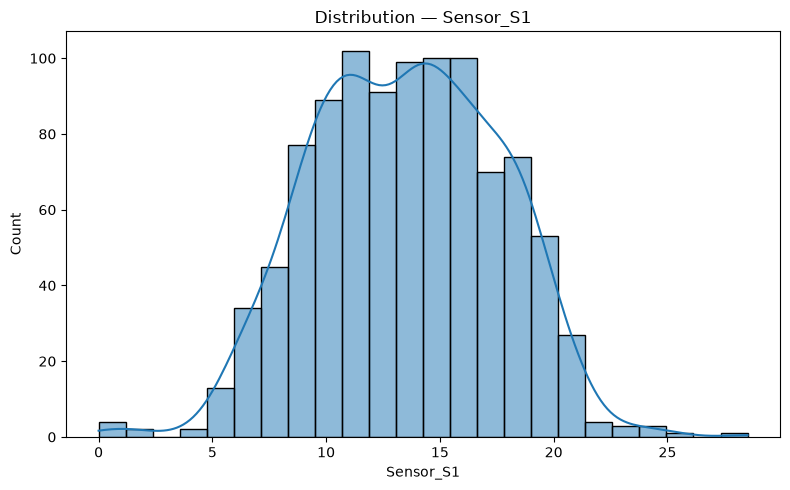

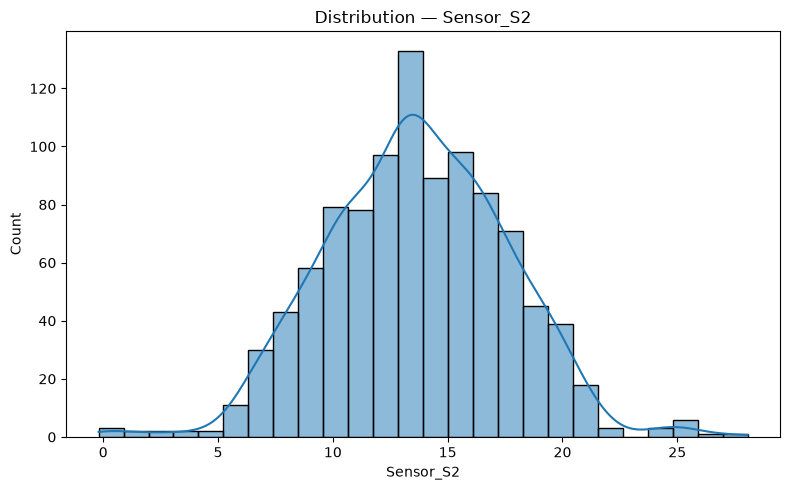

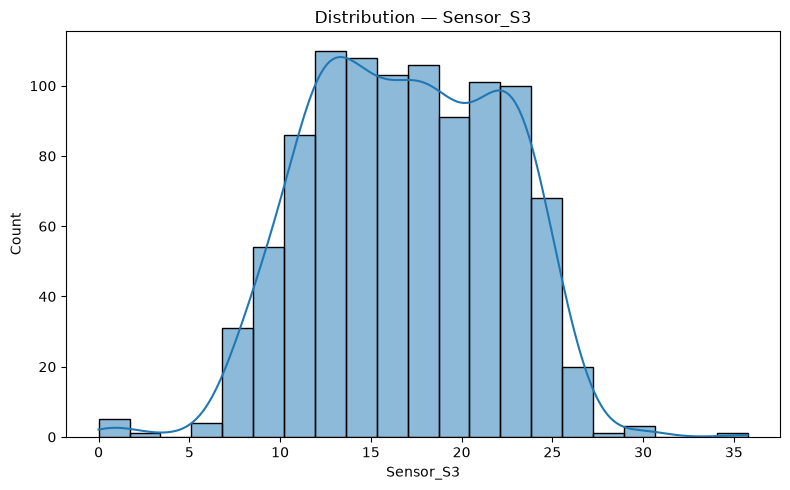

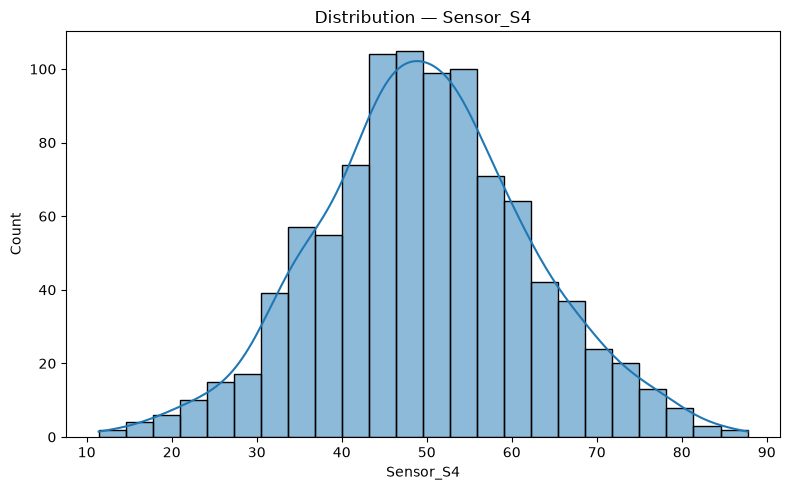

In [25]:
for column in NUMERIC_COLUMNS:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        train_df[column],
        kde=True,
    )

    plt.title(
        f"Distribution — {column}"
    )

    plt.xlabel(column)
    plt.ylabel("Count")

    plt.tight_layout()

    safe_name = column.replace(
        "/",
        "_",
    )

    plt.savefig(
        ROOT
        / "reports"
        / "figures"
        / f"distribution_{safe_name}.png",
        dpi=200,
    )

    plt.show()

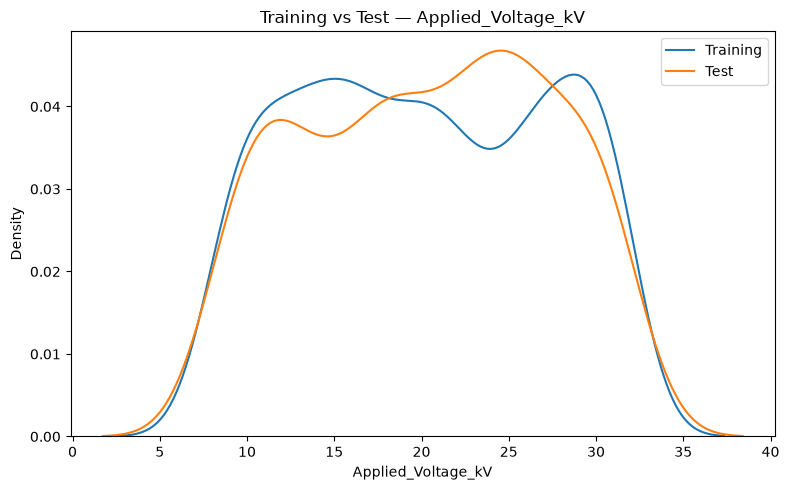

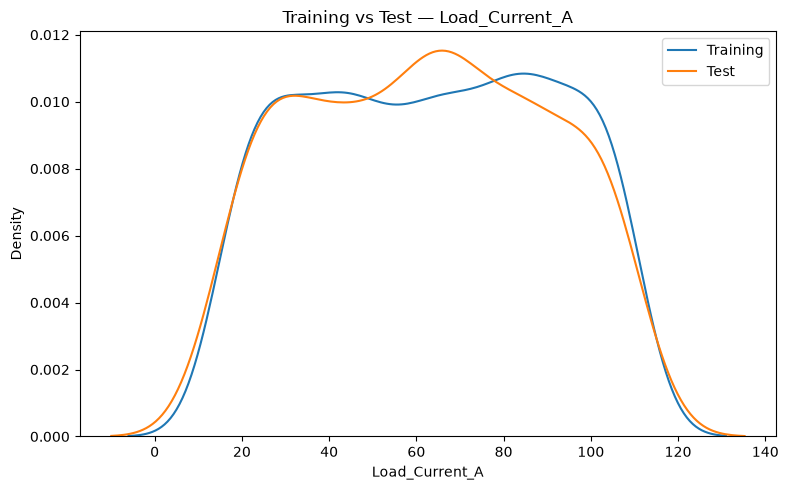

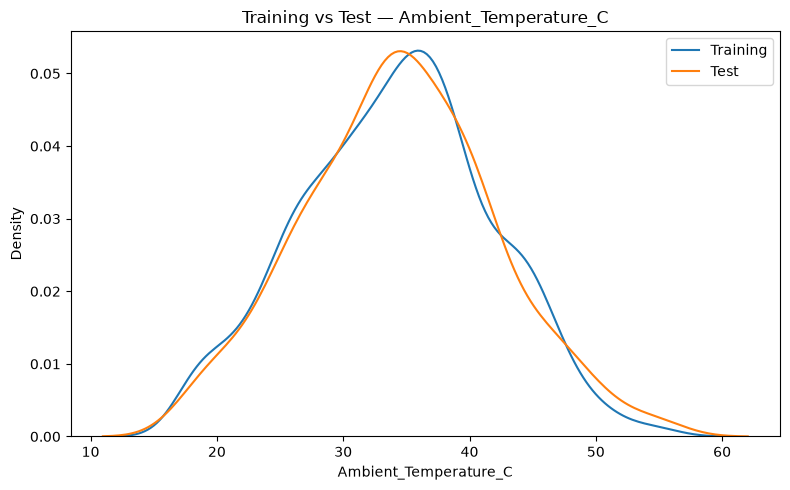

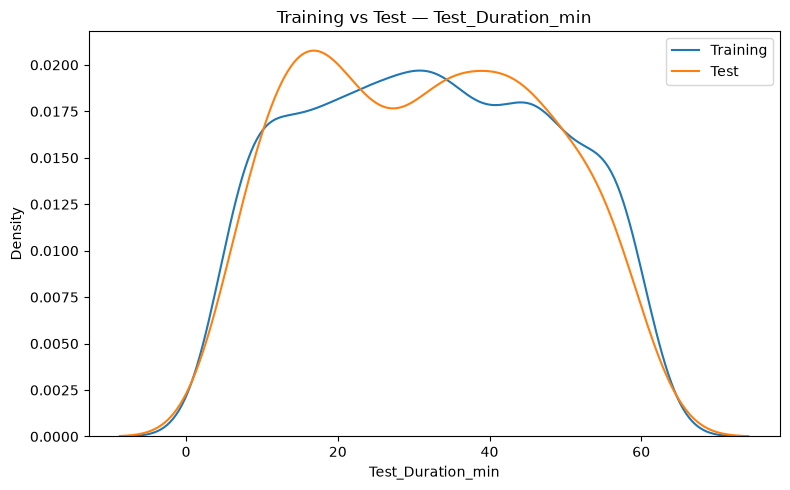

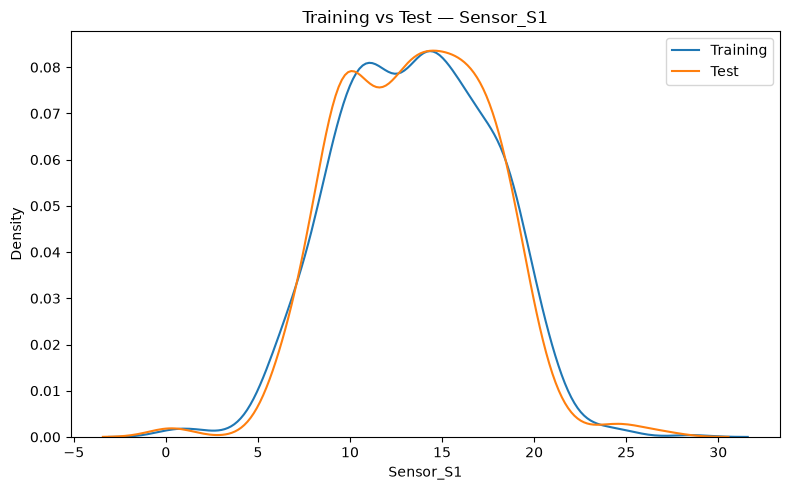

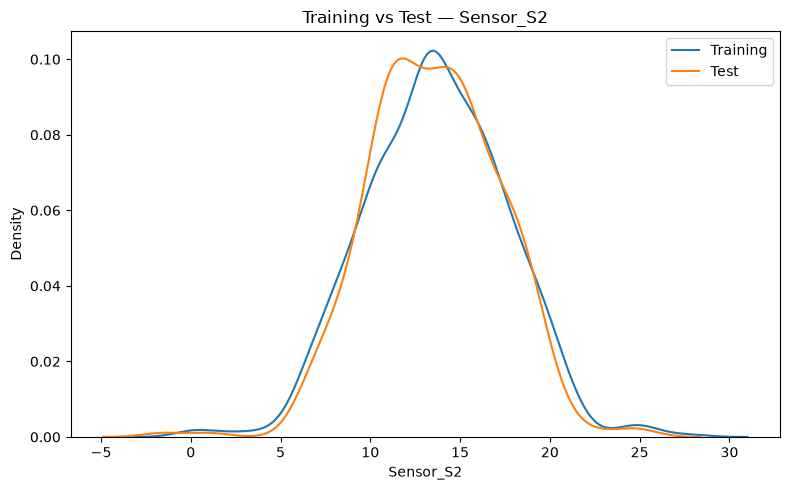

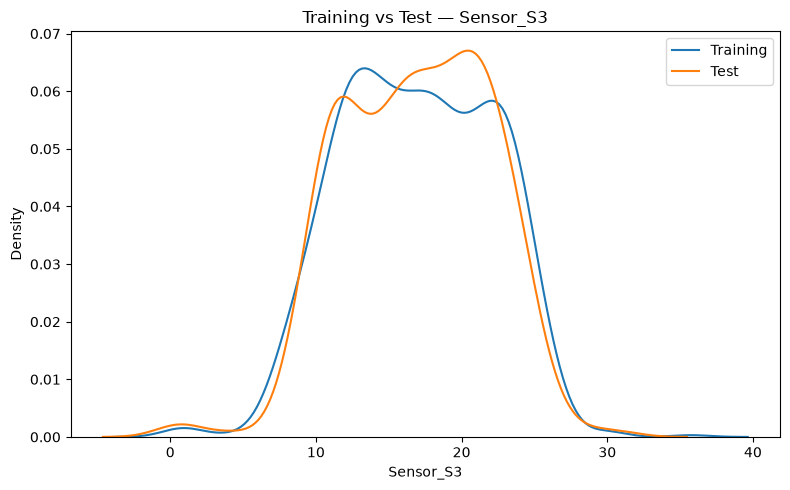

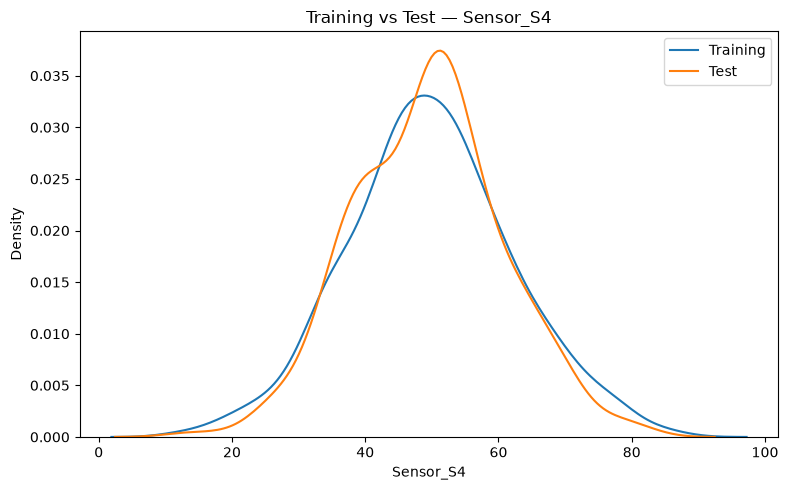

In [26]:
for column in NUMERIC_COLUMNS:

    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        train_df[column],
        label="Training",
    )

    sns.kdeplot(
        test_df[column],
        label="Test",
    )

    plt.title(
        f"Training vs Test — {column}"
    )

    plt.xlabel(column)
    plt.ylabel("Density")

    plt.legend()

    plt.tight_layout()

    safe_name = column.replace(
        "/",
        "_",
    )

    plt.savefig(
        ROOT
        / "reports"
        / "figures"
        / f"train_test_{safe_name}.png",
        dpi=200,
    )

    plt.show()

In [27]:
sensor_corr = valid_df[
    PRIMARY_SENSOR_COLUMNS
].corr(
    method="spearman"
)

display(sensor_corr)

,Sensor_S1,Sensor_S2,Sensor_S3
Sensor_S1,1.000000,0.935393,0.991510
Sensor_S2,0.935393,1.000000,0.887716
Sensor_S3,0.991510,0.887716,1.000000


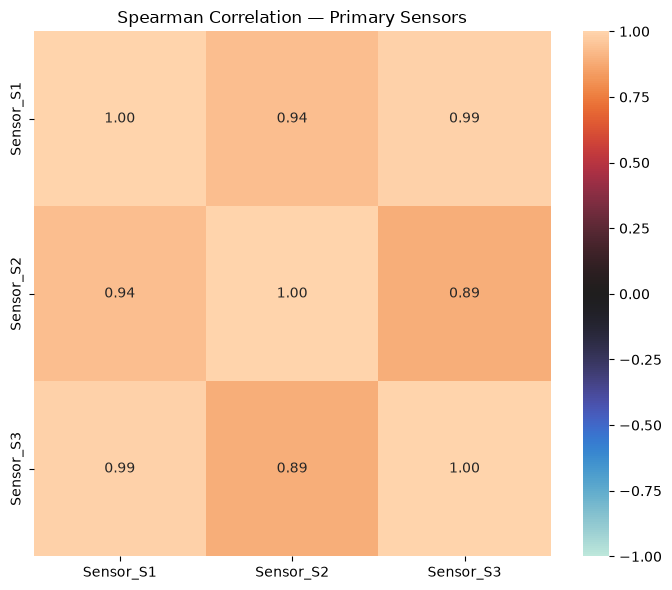

In [28]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    sensor_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
)

plt.title(
    "Spearman Correlation — Primary Sensors"
)

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "04_primary_sensor_correlation.png",
    dpi=200,
)

plt.show()

In [29]:
reference_corr = valid_df[
    NUMERIC_COLUMNS
    + [TARGET_COLUMN]
].corr(
    method="spearman"
)

display(
    reference_corr[TARGET_COLUMN]
    .sort_values(
        ascending=False
    )
)

Reference_Parameter      1.000000
Load_Current_A           0.898381
Sensor_S2                0.852248
Sensor_S1                0.648390
Sensor_S3                0.565146
Applied_Voltage_kV       0.334292
Ambient_Temperature_C    0.216485
Test_Duration_min        0.004863
Sensor_S4               -0.032120
Name: Reference_Parameter, dtype: float64

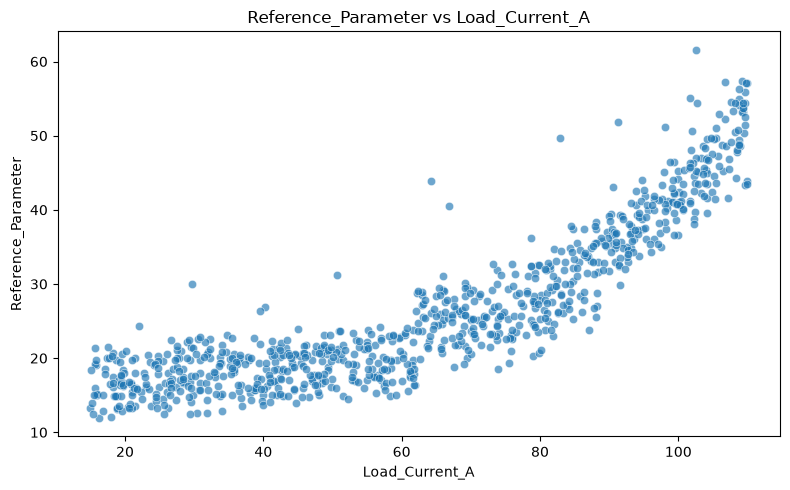

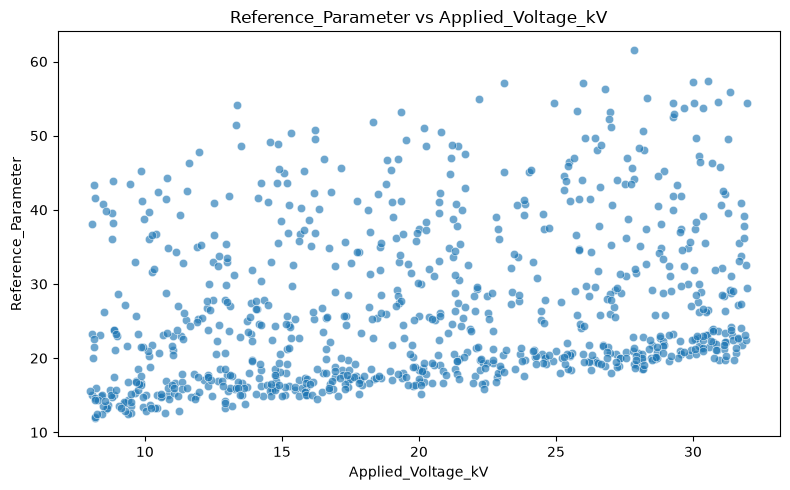

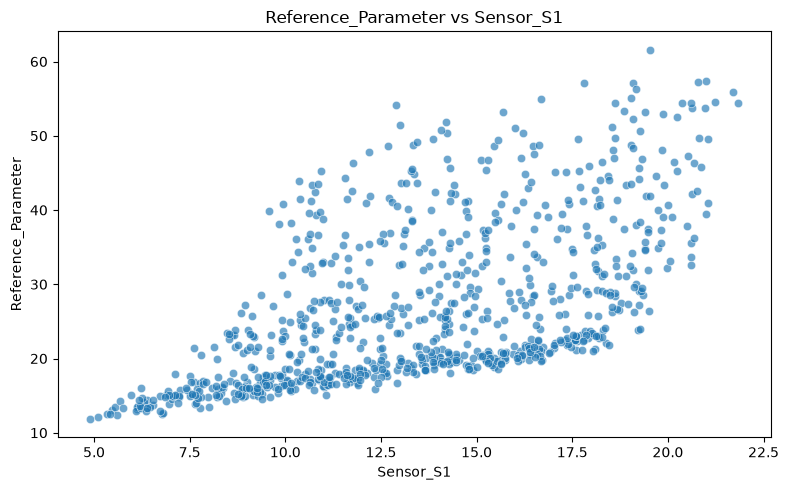

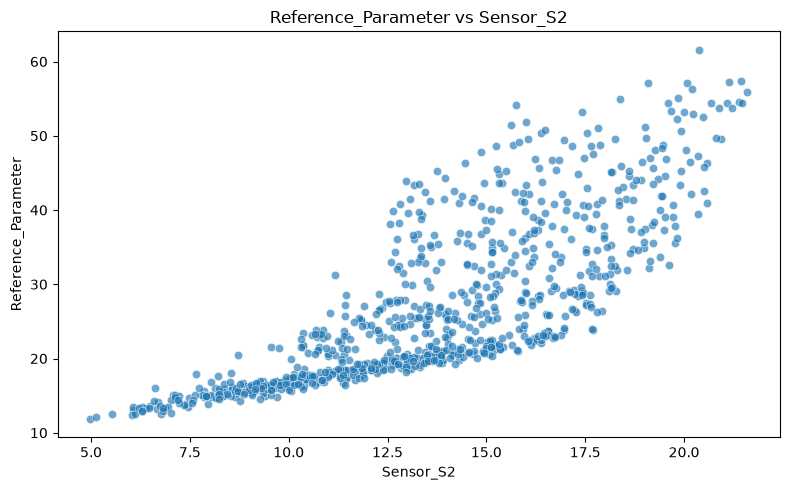

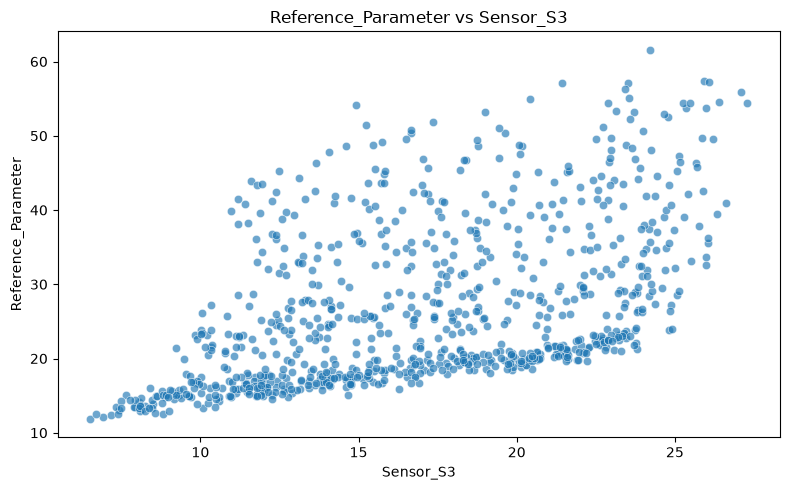

In [30]:
for feature in [
    "Load_Current_A",
    "Applied_Voltage_kV",
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
]:
    
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=valid_df,
        x=feature,
        y=TARGET_COLUMN,
        alpha=0.65,
    )

    plt.title(
        f"{TARGET_COLUMN} vs {feature}"
    )

    plt.tight_layout()

    plt.savefig(
        ROOT
        / "reports"
        / "figures"
        / f"reference_vs_{feature}.png",
        dpi=200,
    )

    plt.show()

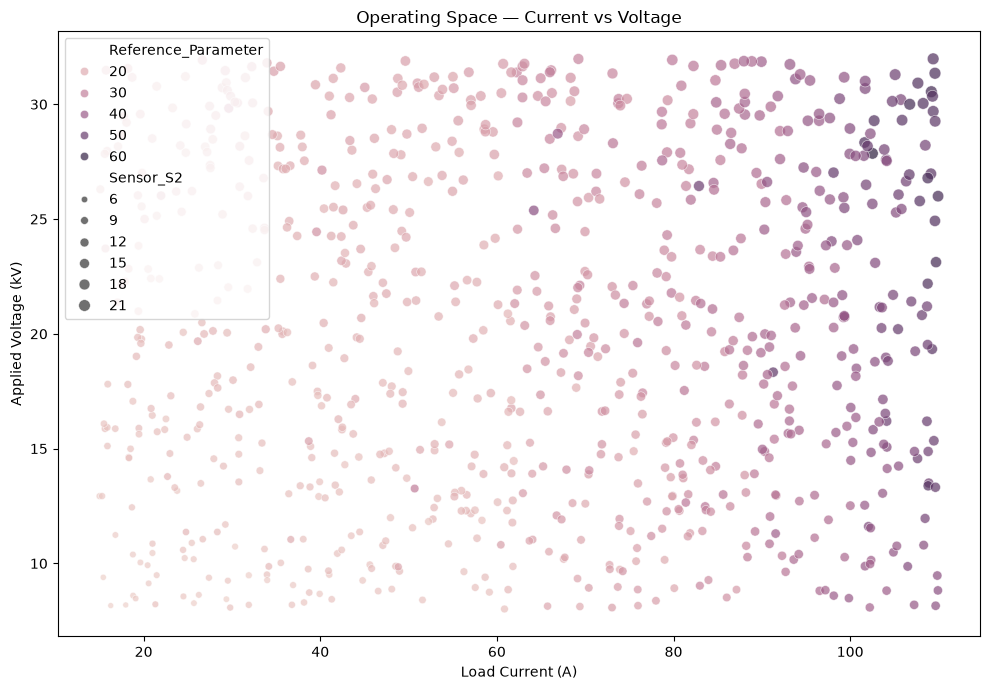

In [31]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=valid_df,
    x="Load_Current_A",
    y="Applied_Voltage_kV",
    hue="Reference_Parameter",
    size="Sensor_S2",
    alpha=0.7,
)

plt.title(
    "Operating Space — Current vs Voltage"
)

plt.xlabel("Load Current (A)")
plt.ylabel("Applied Voltage (kV)")

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "05_operating_space_current_voltage.png",
    dpi=200,
)

plt.show()

In [32]:
from sensor_analysis import (
    add_sensor_consistency_features,
)

valid_consistency = (
    add_sensor_consistency_features(
        valid_df
    )
)

display(
    valid_consistency[
        [
            "S2_minus_S1",
            "S3_minus_S2",
            "S3_minus_S1",
            "Sensor_123_Spread",
            "Max_Absolute_Median_Deviation",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
S2_minus_S1,866.0,0.102064,1.278624,-3.2302,-0.859625,0.15000,1.016500,3.0642
S3_minus_S2,866.0,3.372738,2.374872,-1.8670,1.434425,3.34025,5.245625,8.7529
S3_minus_S1,866.0,3.474802,1.229080,0.8291,2.397075,3.44545,4.579600,5.8265
Sensor_123_Spread,866.0,4.001887,1.741248,1.3588,2.488550,3.66120,5.255525,8.7529
Max_Absolute_Median_Deviation,866.0,3.180672,1.429147,0.7734,1.787350,3.10360,4.488950,5.8265


In [33]:
invalid_consistency = (
    add_sensor_consistency_features(
        invalid_df
    )
)

display(
    invalid_consistency[
        [
            "S2_minus_S1",
            "S3_minus_S2",
            "S3_minus_S1",
            "Sensor_123_Spread",
            "Max_Absolute_Median_Deviation",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
S2_minus_S1,126.0,0.545826,6.554114,-17.64180,-1.762700,0.7378,3.790025,18.0542
S3_minus_S2,125.0,2.872728,6.839819,-14.84300,-0.588700,2.9079,5.994400,21.7538
S3_minus_S1,121.0,3.366493,6.648610,-15.10280,1.349000,3.0052,5.766200,23.1812
Sensor_123_Spread,134.0,7.681825,4.987991,0.10310,3.400300,7.4470,10.890325,23.1812
Max_Absolute_Median_Deviation,134.0,5.834609,4.261660,0.05155,2.267975,5.1521,7.981150,18.0542


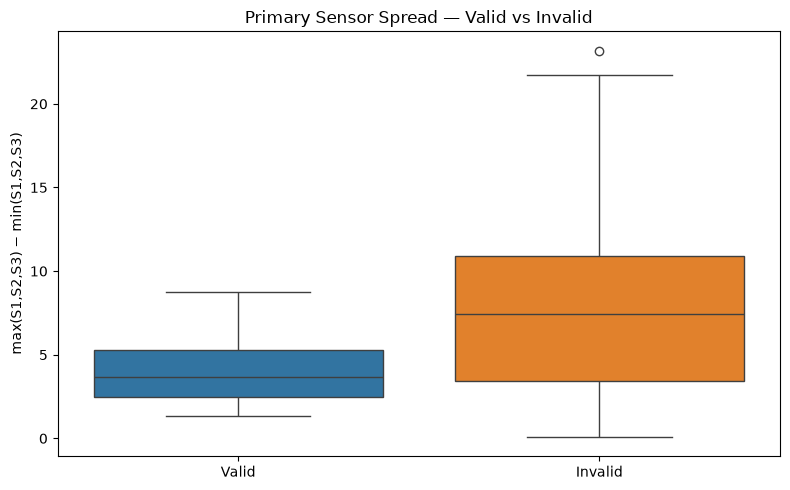

In [34]:
comparison = pd.DataFrame(
    {
        "Valid": valid_consistency[
            "Sensor_123_Spread"
        ].dropna(),
        "Invalid": invalid_consistency[
            "Sensor_123_Spread"
        ].dropna(),
    }
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=comparison,
)

plt.title(
    "Primary Sensor Spread — Valid vs Invalid"
)

plt.ylabel(
    "max(S1,S2,S3) − min(S1,S2,S3)"
)

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "06_sensor_spread_valid_invalid.png",
    dpi=200,
)

plt.show()

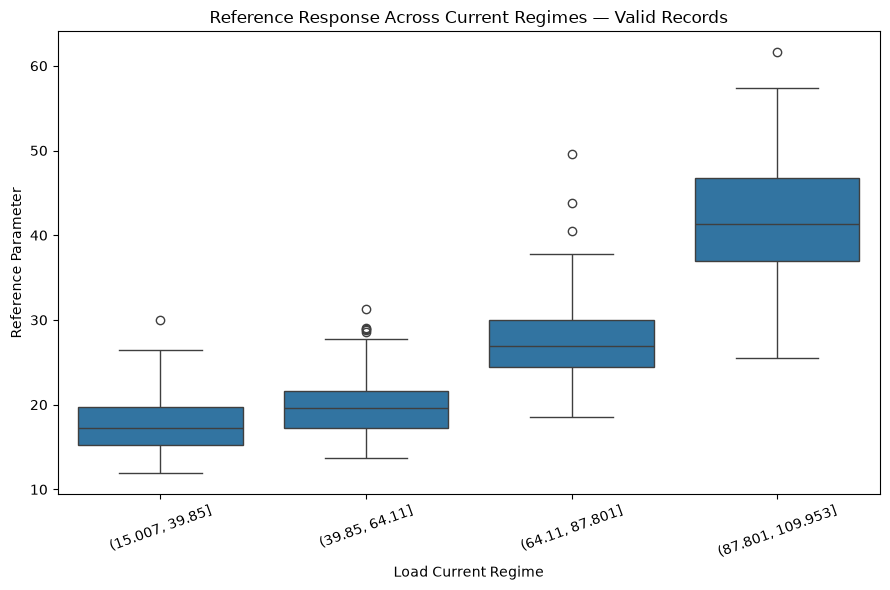

In [35]:
regime_df = valid_df.copy()

regime_df["Current_Regime"] = pd.qcut(
    regime_df["Load_Current_A"],
    q=4,
    duplicates="drop",
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=regime_df,
    x="Current_Regime",
    y="Reference_Parameter",
)

plt.title(
    "Reference Response Across Current Regimes — Valid Records"
)

plt.xlabel("Load Current Regime")
plt.ylabel("Reference Parameter")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    ROOT
    / "reports"
    / "figures"
    / "07_reference_by_current_regime.png",
    dpi=200,
)

plt.show()

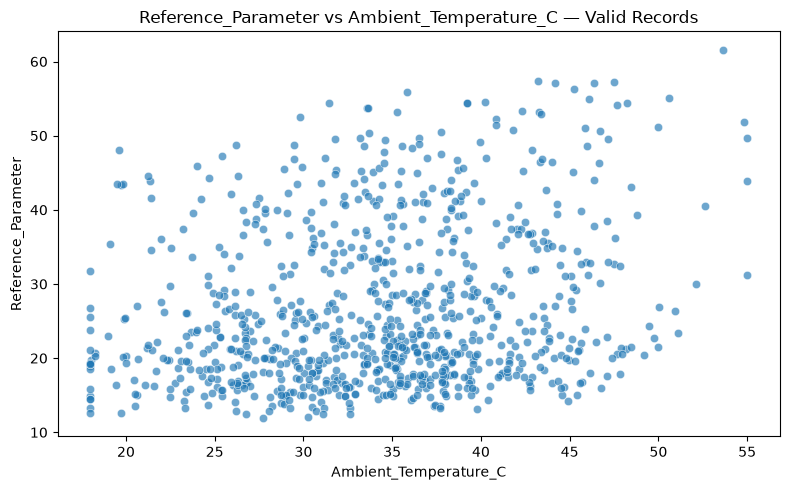

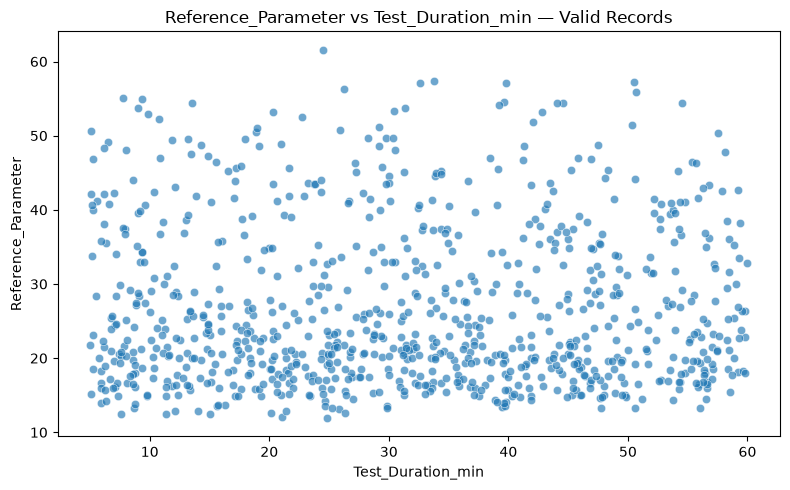

In [36]:
figures = [
    ("Ambient_Temperature_C", "Reference_Parameter"),
    ("Test_Duration_min", "Reference_Parameter"),
]

for x, y in figures:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=valid_df,
        x=x,
        y=y,
        alpha=0.65,
    )

    plt.title(
        f"{y} vs {x} — Valid Records"
    )

    plt.tight_layout()

    plt.savefig(
        ROOT
        / "reports"
        / "figures"
        / f"{y}_vs_{x}.png",
        dpi=200,
    )

    plt.show()

In [37]:
interaction_df = valid_df.copy()

interaction_df["Current_Squared"] = (
    interaction_df["Load_Current_A"] ** 2
)

interaction_df["Voltage_Squared"] = (
    interaction_df["Applied_Voltage_kV"] ** 2
)

interaction_df["Voltage_Current"] = (
    interaction_df["Applied_Voltage_kV"]
    * interaction_df["Load_Current_A"]
)

interaction_df["Current_Ambient"] = (
    interaction_df["Load_Current_A"]
    * interaction_df["Ambient_Temperature_C"]
)

interaction_df["Current_Duration"] = (
    interaction_df["Load_Current_A"]
    * interaction_df["Test_Duration_min"]
)

candidate_columns = [
    "Current_Squared",
    "Voltage_Squared",
    "Voltage_Current",
    "Current_Ambient",
    "Current_Duration",
]

interaction_corr = (
    interaction_df[
        candidate_columns
        + [TARGET_COLUMN]
    ]
    .corr(method="spearman")
    [TARGET_COLUMN]
    .sort_values(
        ascending=False
    )
)

display(interaction_corr)

Reference_Parameter    1.000000
Current_Squared        0.898381
Current_Ambient        0.877487
Voltage_Current        0.856679
Current_Duration       0.544711
Voltage_Squared        0.334292
Name: Reference_Parameter, dtype: float64